# Recommendation System

In [ ]:
# Core data processing
import numpy as np
import pandas as pd
import re

# Database
from sqlalchemy import create_engine, text
from dotenv import load_dotenv, find_dotenv
import psycopg2
import os

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning - Core
from catboost import CatBoostClassifier

# Machine Learning scikit - components
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# Deep Learning components
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DataCollatorWithPadding
from transformers import DataCollatorWithPadding, DistilBertModel, RobertaModel, BertModel, AutoTokenizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lefukuro/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/lefukuro/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [109]:
"""
DATA LOADING FROM DATABASE

 Purpose: Load and combine user, post, and interaction data from PostgreSQL

  users: User demographic information
  posts_text: Post`s content 
  uniq_act: Reactions of all unique users
  acts: Action batch
"""
load_dotenv(dotenv_path='.env', override=True)

def get_engine():
    user = os.getenv("POSTGRES_USER")
    password = os.getenv("POSTGRES_PASSWORD")
    host = os.getenv("POSTGRES_HOST")
    port = os.getenv("POSTGRES_PORT")
    db = os.getenv("POSTGRES_DATABASE")
    
    url = f"postgresql://{user}:{password}@{host}:{port}/{db}"
    
    return create_engine(url)
    


if __name__ == "__main__":
    engine = get_engine()

    users = pd.read_sql("SELECT * FROM public.user_data", con=engine)
    post_text = pd.read_sql("SELECT * FROM public.post_text_df", con=engine)
    uniq_act = pd.read_sql("SELECT DISTINCT ON (user_id, target, action) user_id, post_id, action, timestamp, target FROM public.feed_data WHERE action='view'", con=engine)
    acts = pd.read_sql("SELECT * FROM public.feed_data WHERE action='view' ORDER BY random() LIMIT 3000000", con=engine)

# Combine interaction data: unique actions + sampled interactions
all_actions = pd.concat([uniq_act, acts], axis=0)
df = pd.merge(users, all_actions, on='user_id',how='left')

In [110]:
all_actions

,user_id,post_id,action,timestamp,target
0,200,4912,view,2021-11-07 07:21:42,0
1,200,1587,view,2021-10-29 19:43:15,1
2,201,821,view,2021-12-29 08:30:54,0
3,201,6699,view,2021-10-12 11:08:25,1
4,202,1699,view,2021-11-03 18:45:30,0
...,...,...,...,...,...
2999995,150475,6803,view,2021-12-13 07:58:00,0
2999996,164555,1585,view,2021-11-12 09:37:32,0
2999997,28414,4182,view,2021-11-15 18:29:48,0
2999998,26396,7188,view,2021-12-01 11:05:30,0


## EDA

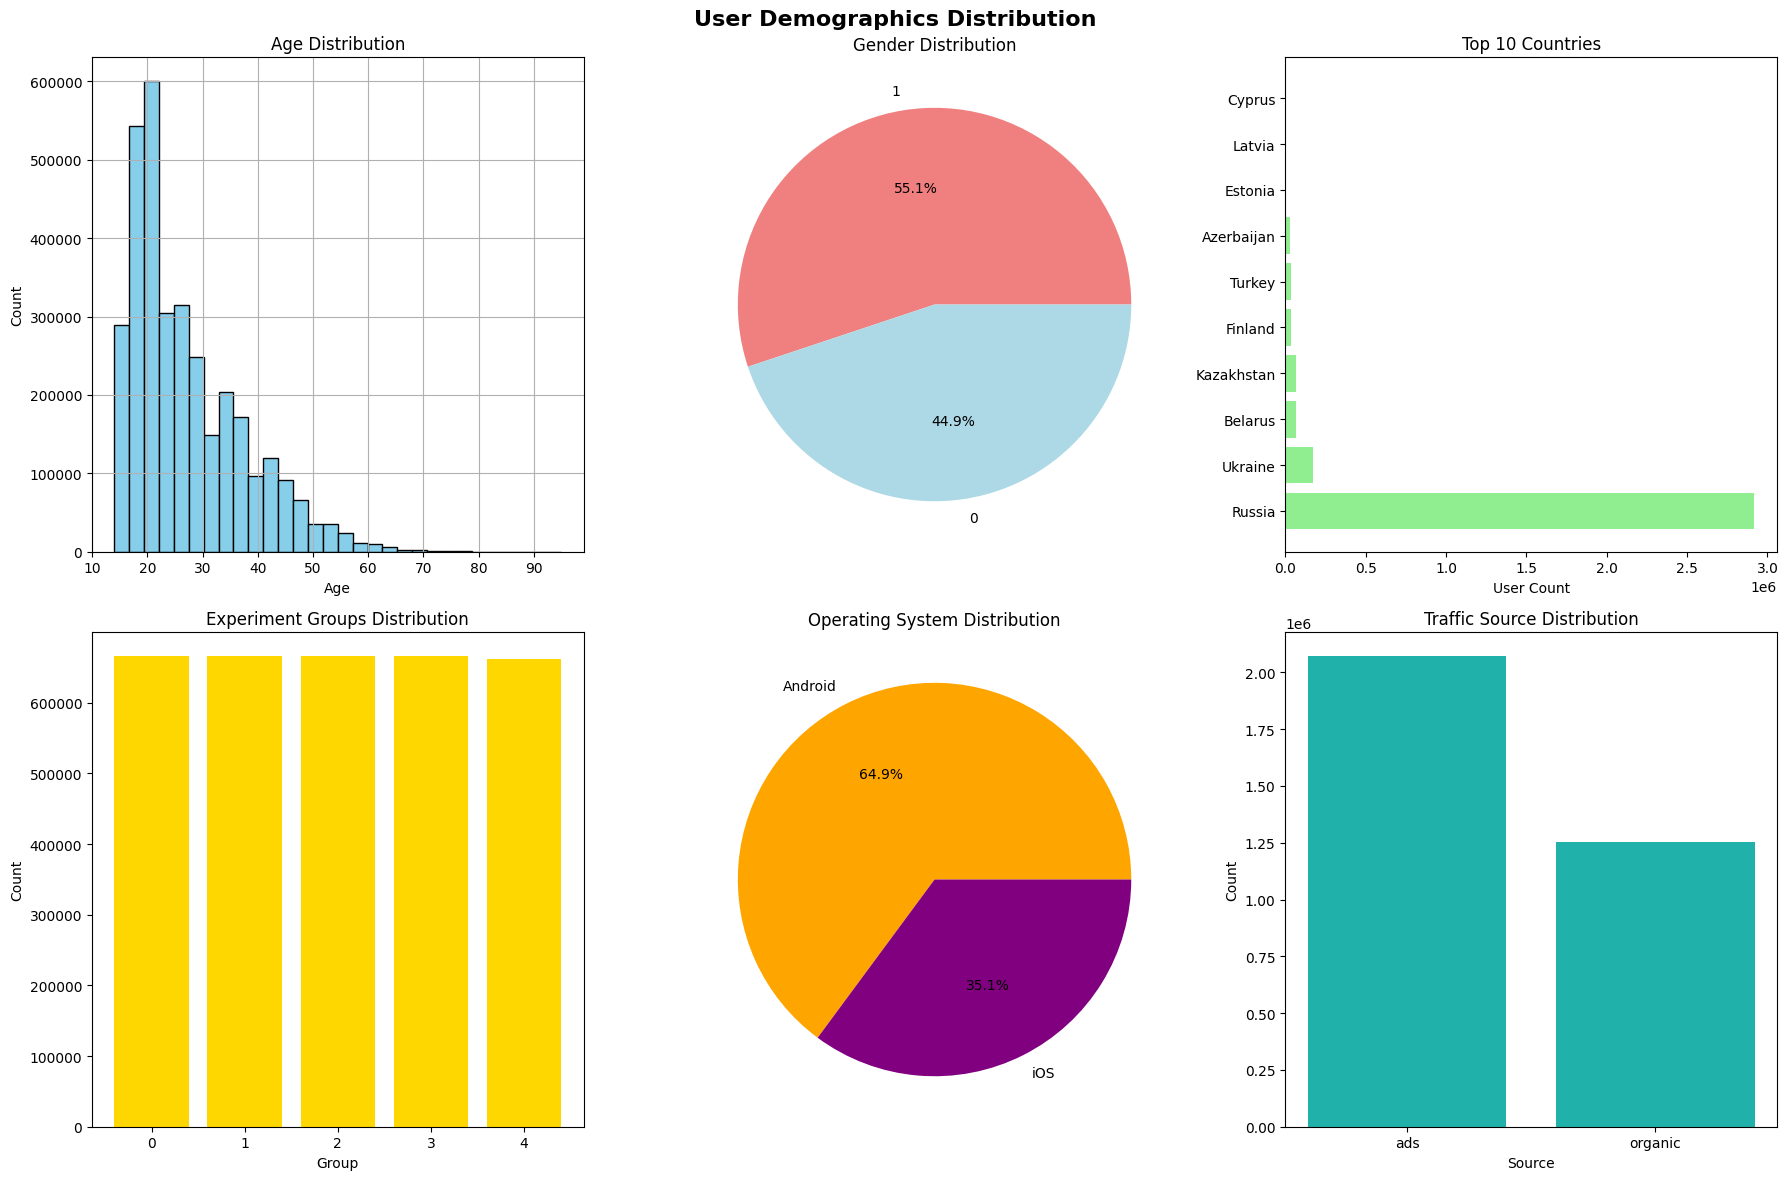

Age statistics:
Mean: 27.2, Median: 24.0
Min: 14, Max: 95
Gender ratio: {1: 1833549, 0: 1492858}


In [111]:
# User demographics analysis

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('User Demographics Distribution', fontsize=16, fontweight='bold')

# Age distribution
df['age'].hist(bins=30, ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# Gender distribution
gender_counts = df['gender'].value_counts()
axes[0,1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
axes[0,1].set_title('Gender Distribution')

# Country distribution
country_top10 = df['country'].value_counts().head(10)
axes[0,2].barh(range(len(country_top10)), country_top10.values, color='lightgreen')
axes[0,2].set_yticks(range(len(country_top10)))
axes[0,2].set_yticklabels(country_top10.index)
axes[0,2].set_title('Top 10 Countries')
axes[0,2].set_xlabel('User Count')

# Experiment groups
exp_counts = df['exp_group'].value_counts()
axes[1,0].bar(exp_counts.index, exp_counts.values, color='gold')
axes[1,0].set_title('Experiment Groups Distribution')
axes[1,0].set_xlabel('Group')
axes[1,0].set_ylabel('Count')

# OS distribution
os_counts = df['os'].value_counts()
axes[1,1].pie(os_counts.values, labels=os_counts.index, autopct='%1.1f%%', colors=['orange', 'purple'])
axes[1,1].set_title('Operating System Distribution')

# Traffic source
source_counts = df['source'].value_counts()
axes[1,2].bar(source_counts.index, source_counts.values, color='lightseagreen')
axes[1,2].set_title('Traffic Source Distribution')
axes[1,2].set_xlabel('Source')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Demographic statistics
print(f"Age statistics:")
print(f"Mean: {df['age'].mean():.1f}, Median: {df['age'].median():.1f}")
print(f"Min: {df['age'].min()}, Max: {df['age'].max()}")
print(f"Gender ratio: {gender_counts.to_dict()}")


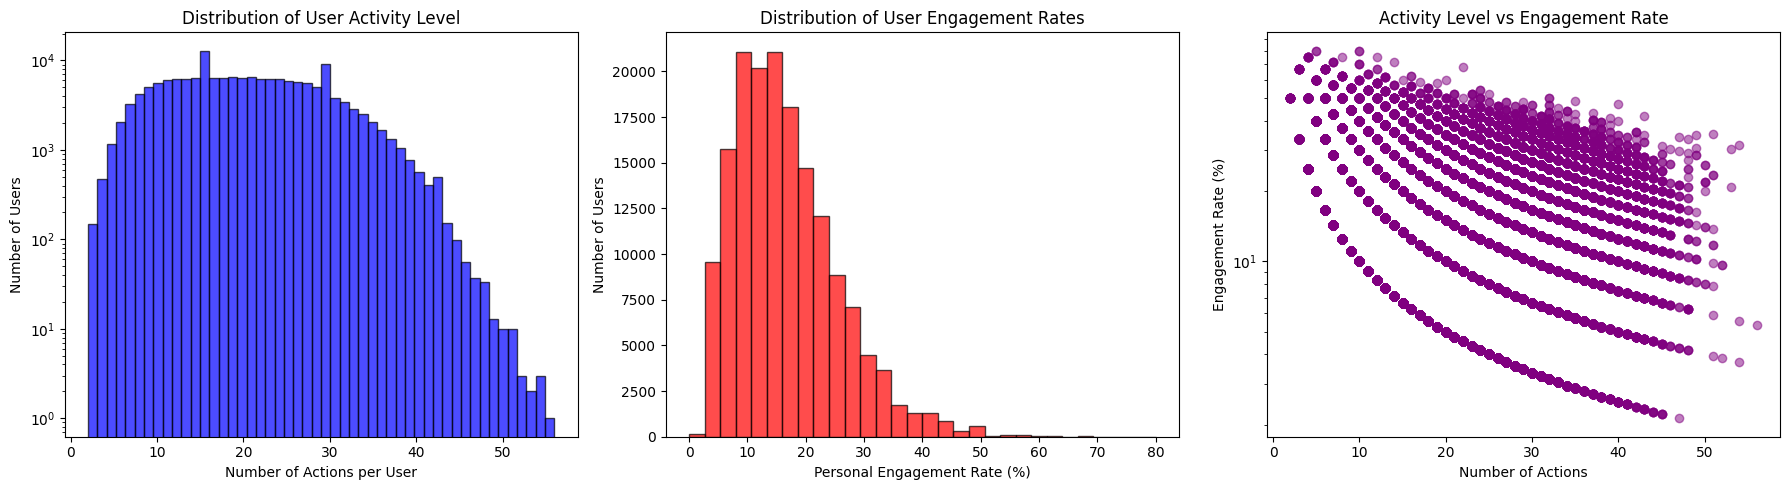

User Behavior Statistics:
Average actions per user: 20.4
Median actions per user: 20.0
Most active user: 56 actions
Average personal engagement rate: 16.61%
Correlation (activity vs engagement): -0.244


In [112]:
# User behavior analysis
fig.suptitle('Content and Engagement Analysis', fontsize=16, fontweight='bold')

# User activity levels
user_activity = df.groupby('user_id').size()
user_engagement = df.groupby('user_id')['target'].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# User activity distribution
axes[0].hist(user_activity, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Distribution of User Activity Level')
axes[0].set_xlabel('Number of Actions per User')
axes[0].set_ylabel('Number of Users')
axes[0].set_yscale('log')

# User engagement distribution
axes[1].hist(user_engagement * 100, bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of User Engagement Rates')
axes[1].set_xlabel('Personal Engagement Rate (%)')
axes[1].set_ylabel('Number of Users')

# Activity vs Engagement scatter
axes[2].scatter(user_activity, user_engagement * 100, alpha=0.5, color='purple')
axes[2].set_title('Activity Level vs Engagement Rate')
axes[2].set_xlabel('Number of Actions')
axes[2].set_ylabel('Engagement Rate (%)')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

print("User Behavior Statistics:")
print(f"Average actions per user: {user_activity.mean():.1f}")
print(f"Median actions per user: {user_activity.median():.1f}")
print(f"Most active user: {user_activity.max()} actions")
print(f"Average personal engagement rate: {user_engagement.mean() * 100:.2f}%")
print(f"Correlation (activity vs engagement): {user_activity.corr(user_engagement):.3f}")

In [113]:
# Display information about the DataFrames
print("Data Info:")
df.info()

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 3326407 entries, 0 to 3326406
Data columns (total 12 columns):
 #   Column     Dtype         
---  ------     -----         
 0   user_id    int64         
 1   gender     int64         
 2   age        int64         
 3   country    str           
 4   city       str           
 5   exp_group  int64         
 6   os         str           
 7   source     str           
 8   post_id    int64         
 9   action     str           
 10  timestamp  datetime64[us]
 11  target     int64         
dtypes: datetime64[us](1), int64(6), str(5)
memory usage: 304.5 MB


In [114]:
df.describe()

,user_id,gender,age,exp_group,post_id,timestamp,target
count,3.326407e+06,3.326407e+06,3.326407e+06,3.326407e+06,3.326407e+06,3326407,3.326407e+06
mean,8.508059e+04,5.512101e-01,2.719435e+01,1.997358e+00,3.398774e+03,2021-11-15 04:35:38.083712,1.571570e-01
min,2.000000e+02,0.000000e+00,1.400000e+01,0.000000e+00,1.000000e+00,2021-10-01 06:01:40,0.000000e+00
25%,4.102800e+04,0.000000e+00,1.900000e+01,1.000000e+00,1.528000e+03,2021-10-23 13:46:09,0.000000e+00
50%,8.552600e+04,1.000000e+00,2.400000e+01,2.000000e+00,3.196000e+03,2021-11-15 06:45:54,0.000000e+00
75%,1.277140e+05,1.000000e+00,3.300000e+01,3.000000e+00,5.210000e+03,2021-12-07 17:14:45,0.000000e+00
max,1.685520e+05,1.000000e+00,9.500000e+01,4.000000e+00,7.319000e+03,2021-12-29 23:51:06,1.000000e+00
std,4.895894e+04,4.973707e-01,1.023520e+01,1.413388e+00,2.095775e+03,NaN,3.639487e-01


# Features engineering

In [115]:
# Calculate overall post popularity metrics
post_popularity = df.groupby('post_id').agg({
    'target': ['count', 'sum', 'mean']  # count = total views, sum = positive interactions, mean = positive ratio
}).round(3)

# Rename columns for better readability
post_popularity.columns = [
    'total_interactions', 
    'positive_interactions', 
    'positive_ratio'
]

# Sort posts by most positive interactions (descending order)
post_popularity = post_popularity.sort_values('positive_interactions', ascending=False)

print("Overall post popularity statistics:")
print(post_popularity.head(10))

# Drop 'action' column as it's only 'view'
df = df.drop('action', axis=1)

# Analyze user interactions with topics
topic_interactions = all_actions.merge(posts_text[['post_id', 'topic']], left_on='post_id', right_on='post_id', how='left')

# Create user-topic interaction matrix (users as rows, topics as columns)
topic_interactions = topic_interactions.groupby(['user_id', 'topic']).size().unstack(fill_value=0)

# Merge feature user-topics interactions with dataset
df = pd.merge(df, topic_interactions, on='user_id', how='left')

print("Statistics on the post topic for each user:")
print(topic_interactions.head(10))

Overall post popularity statistics:
         total_interactions  positive_interactions  positive_ratio
post_id                                                           
1543                   1097                    230           0.210
1538                   1130                    221           0.196
1473                   1105                    220           0.199
1176                   1114                    217           0.195
183                    1150                    215           0.187
1291                   1100                    212           0.193
1774                   1119                    212           0.189
3282                   1105                    211           0.191
1079                   1179                    211           0.179
1250                   1136                    211           0.186
Statistics on the post topic for each user:
topic    business  covid  entertainment  movie  politics  sport  tech
user_id                                       

In [116]:
df

,user_id,gender,age,country,city,exp_group,os,source,post_id,timestamp,target,business,covid,entertainment,movie,politics,sport,tech
0,200,1,34,Russia,Degtyarsk,3,Android,ads,4912,2021-11-07 07:21:42,0,0,3,0,5,4,5,1
1,200,1,34,Russia,Degtyarsk,3,Android,ads,1587,2021-10-29 19:43:15,1,0,3,0,5,4,5,1
2,200,1,34,Russia,Degtyarsk,3,Android,ads,992,2021-11-13 19:46:12,1,0,3,0,5,4,5,1
3,200,1,34,Russia,Degtyarsk,3,Android,ads,5181,2021-12-29 15:04:47,0,0,3,0,5,4,5,1
4,200,1,34,Russia,Degtyarsk,3,Android,ads,1625,2021-10-02 14:11:07,0,0,3,0,5,4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3326402,168552,1,16,Russia,Ivanteyevka,4,Android,organic,5150,2021-12-07 18:41:35,0,0,3,0,10,3,3,1
3326403,168552,1,16,Russia,Ivanteyevka,4,Android,organic,5822,2021-10-12 13:14:37,0,0,3,0,10,3,3,1
3326404,168552,1,16,Russia,Ivanteyevka,4,Android,organic,7311,2021-12-20 19:09:38,0,0,3,0,10,3,3,1
3326405,168552,1,16,Russia,Ivanteyevka,4,Android,organic,7262,2021-10-14 11:17:13,0,0,3,0,10,3,3,1


In [117]:
# Process categorical columns

for col in df.select_dtypes(include='str').columns:
    if df[col].nunique() < 5:
        one_hot = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat((df.drop(col, axis=1), one_hot), axis=1)
    else:
        mean_target = df.groupby(col)['target'].mean()
        df[col] = df[col].map(mean_target)



In [118]:
df

,user_id,gender,age,country,city,exp_group,post_id,timestamp,target,business,covid,entertainment,movie,politics,sport,tech,os_iOS,source_organic
0,200,1,34,0.151084,0.183463,3,4912,2021-11-07 07:21:42,0,0,3,0,5,4,5,1,False,False
1,200,1,34,0.151084,0.183463,3,1587,2021-10-29 19:43:15,1,0,3,0,5,4,5,1,False,False
2,200,1,34,0.151084,0.183463,3,992,2021-11-13 19:46:12,1,0,3,0,5,4,5,1,False,False
3,200,1,34,0.151084,0.183463,3,5181,2021-12-29 15:04:47,0,0,3,0,5,4,5,1,False,False
4,200,1,34,0.151084,0.183463,3,1625,2021-10-02 14:11:07,0,0,3,0,5,4,5,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3326402,168552,1,16,0.151084,0.108473,4,5150,2021-12-07 18:41:35,0,0,3,0,10,3,3,1,False,True
3326403,168552,1,16,0.151084,0.108473,4,5822,2021-10-12 13:14:37,0,0,3,0,10,3,3,1,False,True
3326404,168552,1,16,0.151084,0.108473,4,7311,2021-12-20 19:09:38,0,0,3,0,10,3,3,1,False,True
3326405,168552,1,16,0.151084,0.108473,4,7262,2021-10-14 11:17:13,0,0,3,0,10,3,3,1,False,True


In [119]:
# Text preprocessing and cleaning

# Initialize NLP tools
stop_words = stopwords.words('english')
lemmatizer = WordNetLemmatizer() 

def clean_text(text):
    """
    Clean and preprocess text data by:
    - Converting to lowercase
    - Removing special characters and punctuation
    - Removing stopwords
    - Handling emojis
    """
    
    text = text.lower()  
    
    text = re.sub(r"[^a-zA-Z?.!,¿]+", " ", text)
    punctuations = '@#!?+&*[]-%.:/();$=><|{}^' + "'`" + '_'
    
    for p in punctuations:
        text = text.replace(p,'')
        
    text = [word.lower() for word in text.split() if word.lower() not in stop_words]
    
    def remove_emojis(text):
        return emoji.demojize(text)
   
    text = " ".join(text)
    
    return text

# Apply text cleaning to all posts
posts_text = post_text.copy()   # The original is needed to train the second model
posts_text['text'] = posts_text['text'].apply(lambda x: clean_text(x))

# Create TF-IDF matrix for text feature extraction
tfidf = TfidfVectorizer(max_features = 300)  
tfidf_matrix = tfidf.fit_transform(posts_text['text'].fillna('unknown'))
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

# Reset index for merge later
tfidf_df.reset_index(drop=True, inplace=True)
posts_text.reset_index(drop=True, inplace=True)

In [120]:
# Data standardization for TF-IDF features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tfidf_df)

# Apply PCA (300 features -> 20 components)
pca = PCA(n_components=20) 
X_pca = pca.fit_transform(X_scaled)

# Convert PCA results to DataFrame with descriptive column names
X_pca_df = pd.DataFrame(X_pca).add_prefix('PCA_')

# Extract PCA components (loadings) to analyze feature importance
components = pca.components_

# Create DataFrame showing how original features contribute to each principal component
importance_df = pd.DataFrame(components, columns=tfidf.get_feature_names_out()) 

# Calculate overall feature importance by summing absolute loadings across all components
importance_scores = importance_df.abs().sum(axis=0).sort_values(ascending=False)

print(f"Top 10 most important words by PCA loading:")
print(importance_scores.head(10))




Top 10 most important words by PCA loading:
mobile     1.681074
growth     1.678634
economy    1.654350
seen       1.635134
phone      1.567316
budget     1.499025
users      1.478590
ive        1.456563
firm       1.435645
film       1.416167
dtype: float64


In [121]:
# Apply K-Means clustering to group similar text
kmeans = KMeans(n_clusters=10, random_state=42).fit(X_pca)

# Standardize PCA features
posts_text['TextCluster'] = kmeans.labels_

In [122]:
# Create new feature: text length 
posts_text['text_length'] = posts_text['text'].apply(len)

# One-hot encoding for 'topic' column
one_hot = pd.get_dummies(posts_text['topic'], prefix='topic', drop_first=True)

# Combine all post features with one-hot encoding fot topics
post_final = pd.concat((posts_text.drop('topic', axis=1), one_hot), axis=1)

# Combine post features with posts statistics 
post_final = pd.merge(post_final, post_popularity, on='post_id', how='left')
post_final = post_final.fillna(0)

# Column 'text' is not required for training model
post_final = post_final.drop('text', axis=1)

In [123]:
post_final

,post_id,TextCluster,text_length,topic_covid,topic_entertainment,topic_movie,topic_politics,topic_sport,topic_tech,total_interactions,positive_interactions,positive_ratio
0,1,8,1413,False,False,False,False,False,False,407.0,73.0,0.179
1,2,8,1904,False,False,False,False,False,False,361.0,42.0,0.116
2,3,8,2481,False,False,False,False,False,False,386.0,79.0,0.205
3,4,8,762,False,False,False,False,False,False,394.0,77.0,0.195
4,5,8,673,False,False,False,False,False,False,422.0,77.0,0.182
...,...,...,...,...,...,...,...,...,...,...,...,...
7018,7315,3,484,False,False,True,False,False,False,763.0,157.0,0.206
7019,7316,3,479,False,False,True,False,False,False,345.0,47.0,0.136
7020,7317,3,413,False,False,True,False,False,False,340.0,50.0,0.147
7021,7318,1,466,False,False,True,False,False,False,327.0,32.0,0.098


In [124]:
# Merge all feature sets into final dataset
df_cat = pd.merge(df, post_final, on='post_id', how='left')
df_cat.info()

<class 'pandas.DataFrame'>
RangeIndex: 3326407 entries, 0 to 3326406
Data columns (total 29 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   user_id                int64         
 1   gender                 int64         
 2   age                    int64         
 3   country                float64       
 4   city                   float64       
 5   exp_group              int64         
 6   post_id                int64         
 7   timestamp              datetime64[us]
 8   target                 int64         
 9   business               int64         
 10  covid                  int64         
 11  entertainment          int64         
 12  movie                  int64         
 13  politics               int64         
 14  sport                  int64         
 15  tech                   int64         
 16  os_iOS                 bool          
 17  source_organic         bool          
 18  TextCluster            int32     

In [125]:
# Data type optimization for memory efficiency and model compatibility

# Select only numeric columns for type conversion (exclude categorical/text)
numeric_columns = df_cat.select_dtypes(include=['int64', 'float64']).columns

# Convert numeric columns to float32 to reduce memory usage
df_cat[numeric_columns] = df_cat[numeric_columns].astype('float32')


# Convert timestamp to datetime format for proper time series analysis
df_cat['hour'] = pd.to_datetime(df_cat['timestamp']).apply(lambda x: x.hour)
df_cat['month'] = pd.to_datetime(df_cat['timestamp']).apply(lambda x: x.month)

df_cat = df_cat.set_index(['user_id', 'post_id'])

max(df_cat.timestamp), min(df_cat.timestamp)

(Timestamp('2021-12-29 23:51:06'), Timestamp('2021-10-01 06:01:40'))

# First model training and testing 

In [126]:
# Prepare features and target for model training

df_train = df_cat[df_cat.timestamp < '2021-12-15']
df_test = df_cat[df_cat.timestamp >= '2021-12-15']

df_train = df_train.drop('timestamp', axis=1)
df_test = df_test.drop('timestamp', axis=1)

X_train = df_train.drop('target', axis=1)
X_test = df_test.drop('target', axis=1)

y_train = df_train['target']
y_test = df_test['target']

y_train.shape, y_test.shape

((2766477,), (559930,))

In [127]:
def train_catboost(X_train, y_train, params=None, random_state=42):
    """
    Train CatBoost classifier with hyperparameter tuning using RandomizedSearchCV
    
    Parameters:
    -----------
    X_train : array-like
        Training features
    y_train : array-like
        Training target
    params : dict, optional
        Hyperparameter grid for tuning. If None, uses default grid
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    best_model : CatBoostClassifier
        Trained model with best found parameters
    """
    
    # Initialize base CatBoost model
    catboost_model = CatBoostClassifier(
        loss_function='Logloss',   # Binary classification loss
        verbose=100,               # Progress logging every 100 iterations
        random_state=random_state # Reproducibility
    )
    
    # Default hyperparameter grid for tuning
    if params is None:
        params = {
            'depth': [4, 6, 8],               
            'learning_rate': [0.01, 0.1, 0.2], 
            'iterations': [100, 200],
            'l2_leaf_reg': [1, 3, 5],
        }

    # Hyperparameter tuning with cross-validation
    randomized_search = RandomizedSearchCV(
        catboost_model, 
        params, 
        n_iter=10,
        scoring='roc_auc', 
        cv=3,
        n_jobs=-1,
        random_state=random_state
    )
    
    # Train model with hyperparameter search
    randomized_search.fit(X_train, y_train)    

    # Display tuning results
    print(f"Best parameters: {randomized_search.best_params_}")
    print(f"Best ROC-AUC (CV): {randomized_search.best_score_:.4f}")
    
    return randomized_search.best_estimator_

In [141]:
# Reduce training set size for computational efficiency during development

# Train CatBoost model with optimized hyperparameters
model1 = train_catboost(X_train, y_train)

0:	learn: 0.6239343	total: 1.36s	remaining: 4m 31s
0:	learn: 0.6246898	total: 1.3s	remaining: 2m 8s
0:	learn: 0.6247796	total: 1.11s	remaining: 1m 49s
0:	learn: 0.6238064	total: 1.45s	remaining: 4m 48s
0:	learn: 0.6856846	total: 1.42s	remaining: 4m 42s
0:	learn: 0.6857012	total: 1.49s	remaining: 4m 55s
0:	learn: 0.6237988	total: 1.5s	remaining: 4m 59s
0:	learn: 0.6246801	total: 1.67s	remaining: 2m 45s
99:	learn: 0.3844452	total: 1m 37s	remaining: 0us
99:	learn: 0.3843505	total: 1m 37s	remaining: 0us
99:	learn: 0.3841163	total: 1m 38s	remaining: 0us
0:	learn: 0.6861233	total: 1.02s	remaining: 3m 22s
0:	learn: 0.6856859	total: 1.22s	remaining: 4m 2s
0:	learn: 0.6861304	total: 938ms	remaining: 3m 6s
100:	learn: 0.3816627	total: 1m 58s	remaining: 1m 56s
100:	learn: 0.4255508	total: 1m 58s	remaining: 1m 56s
100:	learn: 0.3818580	total: 1m 59s	remaining: 1m 56s
100:	learn: 0.3822151	total: 2m	remaining: 1m 57s
100:	learn: 0.4255406	total: 2m	remaining: 1m 58s
100:	learn: 0.4335190	total: 1m 

In [142]:
# Analyze feature importance to understand model decision factors

# Extract feature importance scores from trained CatBoost model
feature_importance = model1.get_feature_importance()

# Get feature names from the model
feature_names = model1.feature_names_

# Create sorted DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df)


                  feature  importance
1                     age   26.982178
3                    city   20.430661
22     total_interactions   17.654695
4               exp_group    7.648824
23  positive_interactions    7.632333
24         positive_ratio    6.799827
26                  month    5.020684
25                   hour    2.347862
18            topic_movie    1.021286
8                   movie    0.945167
0                  gender    0.670516
6                   covid    0.576928
2                 country    0.422773
10                  sport    0.403162
15            text_length    0.251833
9                politics    0.213591
5                business    0.194547
17    topic_entertainment    0.178876
7           entertainment    0.162914
14            TextCluster    0.133842
20            topic_sport    0.108861
11                   tech    0.087473
21             topic_tech    0.042428
19         topic_politics    0.022805
16            topic_covid    0.016936
13         s

In [143]:
# Analyze model`s score

print(f"ROC-AUC on train: {roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])}")
print(f"ROC-AUC on test: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}")

ROC-AUC on train: 0.7241241610523945
ROC-AUC on test: 0.6906822712626556


# Second model training and test

Build second model by processing the text with a transformers

In [ ]:
def get_model(model_name):
    assert model_name in ['bert', 'roberta', 'distilbert']

    checkpoint_names = {
        'bert': 'bert-base-cased',             # https://huggingface.co/bert-base-cased
        'roberta': 'roberta-base',             # https://huggingface.co/roberta-base
        'distilbert': 'distilbert-base-cased'  # https://huggingface.co/distilbert-base-cased
    }

    model_classes = {
        'bert': BertModel,
        'roberta': RobertaModel,
        'distilbert': DistilBertModel
    }

    return AutoTokenizer.from_pretrained(checkpoint_names[model_name]), model_classes[model_name].from_pretrained(checkpoint_names[model_name])

In [153]:
class PostDataset(Dataset):
    def __init__(self, texts, tokenizer):
        super().__init__()

        self.texts = tokenizer(
            texts,
            add_special_tokens=True,
            return_token_type_ids=False,
            return_tensors='pt',
            truncation=True,
            padding=True
        )
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        return {'input_ids': self.texts['input_ids'][idx], 'attention_mask': self.texts['attention_mask'][idx]}

    def __len__(self):
        return len(self.texts['input_ids'])

In [145]:
@torch.inference_mode()
def get_embeddings_labels(model, loader):
    model.eval()
    
    total_embeddings = []
    
    for batch in tqdm(loader):
        batch = {key: batch[key].to(device) for key in ['attention_mask', 'input_ids']}

        embeddings = model(**batch)['last_hidden_state'][:, 0, :]

        total_embeddings.append(embeddings.cpu())

    return torch.cat(total_embeddings, dim=0)

In [147]:
tokenizer, model2 = get_model('distilbert')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8748.70it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [148]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model2 = model2.to(device)
print(device)

cpu


In [154]:
dataset = PostDataset(posts_text['text'].values.tolist(), tokenizer)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

loader = DataLoader(dataset, batch_size=32, collate_fn=data_collator, pin_memory=True, shuffle=False)

embeddings = get_embeddings_labels(model2, loader).numpy()
torch.save(embeddings, "distil_embeddings.pt")
embeddings

100%|██████████| 220/220 [09:29<00:00,  2.59s/it]


array([[ 0.1973941 ,  0.12461866, -0.3030703 , ..., -0.20861034,
         0.15626535,  0.20011295],
       [ 0.18218783,  0.0500585 , -0.29461667, ..., -0.28705302,
         0.1386537 ,  0.20453823],
       [ 0.26043317,  0.04969328, -0.3145578 , ..., -0.325829  ,
         0.2800727 ,  0.17759432],
       ...,
       [ 0.3121477 ,  0.14835562, -0.17061932, ..., -0.08972365,
         0.25540012,  0.12273587],
       [ 0.34336984,  0.11383657, -0.17564963, ..., -0.04148015,
         0.27077824,  0.18218762],
       [ 0.09828244, -0.01953299, -0.15506685, ..., -0.04812997,
         0.32761043,  0.22866759]], shape=(7023, 768), dtype=float32)

In [155]:
centered = embeddings - embeddings.mean()

pca = PCA(n_components=30)
pca_decomp = pca.fit_transform(centered)

n_clusters = 10

kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(pca_decomp)

posts_text['TextCluster'] = kmeans.labels_

dists_columns = [f'DistanceToCluster_{i}' for i in range(n_clusters)]

dists_df = pd.DataFrame(
    data=kmeans.transform(pca_decomp),
    columns=dists_columns
)

dists_df.head()

,DistanceToCluster_0,DistanceToCluster_1,DistanceToCluster_2,DistanceToCluster_3,DistanceToCluster_4,DistanceToCluster_5,DistanceToCluster_6,DistanceToCluster_7,DistanceToCluster_8,DistanceToCluster_9
0,1.852315,3.068956,3.099556,2.626706,1.397264,3.039782,2.296791,3.423597,1.647968,3.206341
1,1.400436,3.145424,3.268843,2.337091,1.365640,3.171071,2.241558,3.585810,1.488674,3.272569
2,1.509754,3.184673,3.460871,2.280736,2.037211,3.469236,2.519756,3.818551,1.660538,3.240507
3,2.147962,3.184510,3.079812,2.858293,2.596642,3.075513,2.952012,3.611143,2.134831,3.326010
4,1.728553,2.485756,2.950097,2.098973,2.214220,2.693268,2.113917,2.948486,1.098292,2.378276


In [ ]:
posts_text_emb = pd.concat((post_text, dists_df), axis=1)

posts_text_emb.head()

,post_id,text,topic,TextCluster,DistanceToCluster_0,DistanceToCluster_1,DistanceToCluster_2,DistanceToCluster_3,DistanceToCluster_4,DistanceToCluster_5,DistanceToCluster_6,DistanceToCluster_7,DistanceToCluster_8,DistanceToCluster_9,DistanceToCluster_10,DistanceToCluster_11,DistanceToCluster_12,DistanceToCluster_13,DistanceToCluster_14
0,1,UK economy facing major risks\n\nThe UK manufa...,business,8,3.331698,3.345263,3.580764,2.887658,2.800669,3.401343,2.391398,3.536436,1.394383,1.825610,3.443339,3.362653,3.386936,3.516983,2.243963
1,2,Aids and climate top Davos agenda\n\nClimate c...,business,9,3.263629,3.270344,3.344939,2.708366,2.454334,3.048719,2.269865,3.208125,2.058298,1.548883,3.184665,3.264791,2.879958,3.304715,2.135160
2,3,Asian quake hits European shares\n\nShares in ...,business,9,3.166924,3.387391,3.308719,2.919321,2.770511,3.035568,2.284367,3.170139,2.135444,1.396752,3.318096,3.282412,2.863899,3.385171,2.996535
3,4,India power shares jump on debut\n\nShares in ...,business,9,3.465176,3.683802,3.133837,3.174716,3.309569,3.704340,2.762038,3.747425,2.605255,2.241496,4.018127,3.684565,3.650286,3.564927,3.380512
4,5,Lacroix label bought by US firm\n\nLuxury good...,business,9,2.908709,2.632507,2.960162,2.481377,1.957217,2.653009,1.791158,2.820282,1.835063,1.525311,3.129480,2.677832,2.493286,2.997427,2.868276


In [ ]:
model1.feature_importance_

Index(['gender', 'age', 'country', 'city', 'exp_group', 'timestamp', 'target',
       'business', 'covid', 'entertainment', 'movie', 'politics', 'sport',
       'tech', 'os_iOS', 'source_organic', 'TextCluster', 'text_length',
       'topic_covid', 'topic_entertainment', 'topic_movie', 'topic_politics',
       'topic_sport', 'topic_tech', 'total_interactions',
       'positive_interactions', 'positive_ratio', 'hour', 'month'],
      dtype='str')

In [136]:
X_train.info()

<class 'pandas.DataFrame'>
MultiIndex: 2766477 entries, (np.float32(200.0), np.float32(4912.0)) to (np.float32(168552.0), np.float32(3009.0))
Data columns (total 27 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   gender                 float32
 1   age                    float32
 2   country                float32
 3   city                   float32
 4   exp_group              float32
 5   business               float32
 6   covid                  float32
 7   entertainment          float32
 8   movie                  float32
 9   politics               float32
 10  sport                  float32
 11  tech                   float32
 12  os_iOS                 bool   
 13  source_organic         bool   
 14  TextCluster            int32  
 15  text_length            float32
 16  topic_covid            bool   
 17  topic_entertainment    bool   
 18  topic_movie            bool   
 19  topic_politics         bool   
 20  topic_sport            bool 